# Qual é o melhor plano?

Você trabalha como analista para a empresa de telecomunicações Megaline. A empresa oferece aos clientes dois planos pré-pagos: Surf e Ultimate. O departamento comercial quer saber qual dos planos gera mais receita para ajustar o orçamento de publicidade.

Você vai realizar uma análise preliminar dos planos com base em uma pequena seleção de clientes. Você terá dados de 500 clientes da Megaline: que clientes são, de onde eles são, qual plano usam e o número de chamadas e mensagens realizadas em 2018. Seu trabalho é analisar o comportamento dos clientes e determinar qual plano pré-pago gera mais receita.

****

**O principal objetivo neste projeto será determinar qual dos planos pré-pagos da empresa Megaline, Surf ou Ultimate, gera mais receita para a empresa usando os dados de 500 clientes como base. Esta análise será fundamental para que a Megaline possa otimizar a publicidade, direcionando-a para o plano mais lucrativo.**

**A primeira ação que deverei fazer será carregar e analisar os dataframes fornecidos. Isso será essencial para entender a estrutura dos dados e identificar possíveis problemas (como valores ausentes ou tipos de dados incorretos).**

**Depois, se nacessário, deverei realizar um pré-processamento de dados, tratando de valores ausentes e corrigindo tipos de dados e os enriquecendo se possível.**

**Após isso, irei calcular a receita gerada por cada cliente de ambos os planos, Isso envolve considerar a taxa mensal de cada plano e o custo adicional por minuto de chamada ou mensagem que exceder o limite do plano.**

**Depois Verificarei como a receita se distribui entre os clientes de cada plano.**

**Por fim, usando diversos gráficos, apresentarei uma conclusão clara sobre qual plano gera mais receita com base nos resultados da análise.**

****

## Inicialização

In [1]:
# Carregando todas as bibliotecas
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats as st
import seaborn as sns

## Carregue os dados

In [2]:
# Carregue os arquivos de dados em diferentes DataFrames
df_users = pd.read_csv('megaline_users.csv')
df_calls = pd.read_csv('megaline_calls.csv')
df_messages = pd.read_csv('megaline_messages.csv')
df_internet = pd.read_csv('megaline_internet.csv')
df_plans = pd.read_csv('megaline_plans.csv')

## Prepare os dados

## Planos

In [3]:
# Imprima informações gerais/resumo sobre o DataFrame dos planos
print(df_plans.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes
None


In [4]:
# Imprima uma amostra de dados dos planos
print(df_plans.head())

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


****

**Os dados dos dois planos parecem ok exceto pelo tipo de dados nas colunas 'usd_monthly_pay' e 'usd_per_gb' que estão classificadaa como números inteiros, como um valor monetário pode ser dividido entre valores inteiros e centavos, faz mais sentido converte-los para o tipo float.**

****

## Corrija os dados

In [5]:
#Converte o tipo das colunas 'usd_monthly_pay' e 'usd_per_gb' de int para float
df_plans['usd_monthly_pay'] = df_plans['usd_monthly_pay'].astype(float)
df_plans['usd_per_gb'] = df_plans['usd_per_gb'].astype(float)
print(df_plans.head())
print(df_plans.info())

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0             20.0        10.0             0.03            0.03      surf  
1             70.0         7.0             0.01            0.01  ultimate  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      float64
 4   usd_per_gb             2 non-null      float64
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   pla

## Enriqueça os dados

****

**Os dados deste dataframe estão em bom estado e não precisam de mais enriquecimento.**

****

## Usuários

In [6]:
# Imprima informações gerais/resumo sobre o DataFrame dos usuários
print(df_users.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
None


In [7]:
# Imprima uma amostra de dados dos usuários
print(df_users.sample(10))


     user_id  first_name   last_name  age  \
40      1040       Paris      Santos   72   
446     1446    Pasquale        Ball   52   
19      1019      Shizue      Landry   34   
42      1042  Clementina  Mclaughlin   40   
200     1200      Delmar       Cross   45   
372     1372      Patria         Kim   26   
184     1184     Fredric   Middleton   39   
25      1025        Jess   Wilkinson   64   
94      1094      Walter    Petersen   54   
28      1028    Jefferey   Rasmussen   57   

                                                city    reg_date      plan  \
40   Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA  2018-12-23      surf   
446             Austin-Round Rock-Georgetown, TX MSA  2018-09-10      surf   
19                              Jacksonville, FL MSA  2018-01-16      surf   
42   Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA  2018-01-15      surf   
200               Boston-Cambridge-Newton, MA-NH MSA  2018-11-27      surf   
372        New York-Newark-Jersey Ci

****

**Os dados das colunas 'reg_date' e 'churn_date' estão como string, o que pode atrapalhar em análises temporais apresentam problemas, além de que 'churn_date' apresenta vários valores ausentes.**

****

### Corrija os dados

In [8]:
#Converte as colunas 'reg_date' e 'churn_date' para datetime
df_users['reg_date'] = pd.to_datetime(df_users['reg_date'])

#Ao converter 'churn_date' para o tipo datetime, todos os valores ausentes serão convertidos de NaN (Not a Number) para NaT (Not a Time) 
#que indica uma data ausente, pode valer a pena manter os valores audentes assim pois indica que o cliente não cancelou o plano pré pago ainda
df_users['churn_date'] = pd.to_datetime(df_users['churn_date'])

print(df_users.sample(10))

     user_id first_name   last_name  age  \
426     1426     Lamont      Conner   44   
133     1133      Larry        Barr   50   
308     1308     Samara      Monroe   46   
474     1474     Randee   Carpenter   26   
260     1260       Alia     Aguilar   36   
390     1390    Deloras  Strickland   61   
251     1251     Tifany       Mcgee   45   
310     1310    Vincent         Fry   73   
465     1465    Arianna    Morrison   73   
332     1332      Lucas    Saunders   37   

                                               city   reg_date      plan  \
426          San Francisco-Oakland-Berkeley, CA MSA 2018-07-09  ultimate   
133                        Cincinnati, OH-KY-IN MSA 2018-07-21  ultimate   
308  Virginia Beach-Norfolk-Newport News, VA-NC MSA 2018-11-22      surf   
474                             Bakersfield, CA MSA 2018-08-26      surf   
260          Los Angeles-Long Beach-Anaheim, CA MSA 2018-12-02      surf   
390          Chicago-Naperville-Elgin, IL-IN-WI MSA 2018-03

### Enriqueça os dados

In [9]:
#Um fator que pode ser útil para a análise seria agrupar cada data de registro a partir de seus meses pois pode ser útil 
#na hora de determinar os períodos do ano em que se há mais novos usuários

#Cria uma nova coluna chamada 'is_churned' que diz se o usuário cancelou o plano ou não usando um valor booleano
df_users['is_churned'] = df_users['churn_date'].notna()

#Cria uma nova coluna chamada 'month' que separa cada data de registro por mês
df_users['month'] = df_users['reg_date'].dt.month_name()

print(df_users.info())
print(df_users.sample(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
 8   is_churned  500 non-null    bool          
 9   month       500 non-null    object        
dtypes: bool(1), datetime64[ns](2), int64(2), object(5)
memory usage: 35.8+ KB
None
     user_id first_name last_name  age  \
295     1295       Hung   Flowers   68   
261     1261      Dusti    Forbes   31   
90      1090      Brock   Skinner   30   
154     1154   Humberto    Pruitt   53   
147     1147     Duncan  

## Chamadas

In [10]:
# Imprima informações gerais/resumo sobre o DataFrame das chamadas
print(df_calls.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
None


In [11]:
# Imprima uma amostra de dados das chamadas
print(df_calls.sample(10))


              id  user_id   call_date  duration
94630   1336_517     1336  2018-12-31      5.78
72641   1257_381     1257  2018-10-18     14.41
23828   1088_323     1088  2018-11-05      0.00
127076   1454_66     1454  2018-08-22     12.70
55237   1197_225     1197  2018-11-23      4.83
49508   1179_167     1179  2018-11-12      2.13
30859   1115_213     1115  2018-11-28      0.00
61467   1222_114     1222  2018-10-24      0.00
19326   1073_159     1073  2018-04-11      0.00
91447   1329_378     1329  2018-09-17     10.19


****

**Os dados da data da ligação estão como string, o que pode atrapalhar em análises temporais e alguns valores na duração da chamada que constam como 0, o que não faz muito sentido se estivermos falando de uma ligação telefônica.**

****

### Corrija os dados

In [12]:
#Para facilitar na leitura e filtragem na coluna 'call_date' o código a seguir irá converte-la de object para datetime.
df_calls['call_date'] = pd.to_datetime(df_calls['call_date'])

print(df_calls.sample(10))

              id  user_id  call_date  duration
29750   1112_414     1112 2018-10-11     10.53
32819   1123_177     1123 2018-11-10      0.10
49830    1181_34     1181 2018-12-20      0.00
17362   1066_471     1066 2018-03-14      3.50
65456    1237_63     1237 2018-09-23     11.26
54869   1196_766     1196 2018-02-25      8.37
113634  1399_258     1399 2018-12-02      4.77
131510  1472_548     1472 2018-07-05      0.00
28532   1109_159     1109 2018-08-18      1.02
8451    1039_391     1039 2018-06-25      5.53


### Enriqueça os dados

In [13]:
#Um fator que pode ser útil para a análise seria agrupar cada ligação a partir de seus meses pois pode ser útil 
#na hora de determinar os períodos do ano em que os usuários são mais ativos

#Cria a coluna 'month' usando informações das linhas da coluna 'call_date'
df_calls['month'] = df_calls['call_date'].dt.month_name()

#Cria a coluna 'call_satus' usando informações das linhas da coluna 'duration'
#Como há várias durações que possuem o valor como 0.00, pode-se assumir que essas chamadas foram não atendidas ou recusadas, 
#o código a seguir determinará se a chamada foi atendida ou não ('Declined/Unawsered' para duração 0.00 e 'Complete' para chamadas atentidas)
#Originalmente pretendia substituir todos os valores iguais a 0.00 diretamente na coluna 'duration', mas reparei que ao fazer isso a coluna deixa de ser float e vira object, o que pode atrapalhar em futuros cálculos.
df_calls['call_status'] = np.where(df_calls['duration'] == 0, 'Declined/Unawsered', 'Complete')

print(df_calls.info())
print(df_calls.sample(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   id           137735 non-null  object        
 1   user_id      137735 non-null  int64         
 2   call_date    137735 non-null  datetime64[ns]
 3   duration     137735 non-null  float64       
 4   month        137735 non-null  object        
 5   call_status  137735 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 6.3+ MB
None
              id  user_id  call_date  duration      month         call_status
123614  1436_325     1436 2018-09-06     12.12  September            Complete
24235     1091_3     1091 2018-11-22     10.18   November            Complete
13636    1058_26     1058 2018-11-07     12.09   November            Complete
4594     1020_72     1020 2018-12-03      6.55   December            Complete
65724   1237_3

## Mensagens

In [14]:
# Imprima informações gerais/resumo sobre o DataFrame das mensagens
print(df_messages.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None


In [15]:
# Imprima uma amostra dos dados das mensagens
print(df_messages.sample(10))


             id  user_id message_date
71063  1462_171     1462   2018-10-19
57325  1362_404     1362   2018-05-10
36013   1237_34     1237   2018-11-02
14116  1098_119     1098   2018-12-31
47802  1324_522     1324   2018-12-01
52866    1339_0     1339   2018-12-22
36508  1242_180     1242   2018-12-09
75457  1491_305     1491   2018-10-31
42947  1281_215     1281   2018-08-03
65716   1424_29     1424   2018-12-13


****

**Os dados parecem ok no geral porém a coluna 'message_date' está classificada como uma string, o ideal para um valor em data seria converte-lo para datetime.**

****

### Corrija os dados

In [16]:
#Converte 'message_date' de object para datetime
df_messages['message_date'] = pd.to_datetime(df_messages['message_date'])

print(df_messages.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB
None


### Enriqueça os dados

In [17]:
#Pode valer a pena criar uma nova coluna para registrar o mês das mensagens 
#pois pode ser útil na hora de determinar o período do ano em que os usuários usam os planos mais ativamente

df_messages['month'] = df_messages['message_date'].dt.month_name()

print(df_messages.info())
print(df_messages.sample(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
 3   month         76051 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 2.3+ MB
None
             id  user_id message_date     month
53823   1341_99     1341   2018-11-11  November
28799  1175_115     1175   2018-12-01  December
10979  1077_250     1077   2018-05-22       May
5799   1054_166     1054   2018-10-16   October
25795  1155_170     1155   2018-04-29     April
45825   1313_21     1313   2018-08-23    August
64795   1414_11     1414   2018-10-13   October
52398  1336_377     1336   2018-11-09  November
33861   1213_67     1213   2018-11-27  November
23882  1144_373     1144   2018-11-22 

## Internet

In [18]:
# Imprima informações gerais/resumo sobre o DataFrame da internet
print(df_internet.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
None


In [19]:
#  Imprima uma amostra de dados para o tráfego da internet
print(df_internet.sample(10))


             id  user_id session_date  mb_used
2934   1016_160     1016   2018-11-07   804.52
10636  1054_171     1054   2018-12-26     0.00
36929   1166_95     1166   2018-10-22     0.00
69989  1327_129     1327   2018-12-08   301.31
85318   1398_69     1398   2018-12-17   556.09
77658  1362_338     1362   2018-11-14   427.50
81866   1384_64     1384   2018-07-08   212.38
85686  1399_298     1399   2018-11-06   502.62
8995   1046_280     1046   2018-09-24     0.00
70107   1328_66     1328   2018-10-16   740.10


****

**A coluna 'session_date' está classificada como uma string, o ideal para um valor em data seria converte-lo para datetime, além de que há diversas sessões de internet que não gastaram nenhum megabyte.**

****

### Corrija os dados

In [20]:
#Converte 'session_date' de object para datetime
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'])

print(df_internet.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB
None


### Enriqueça os dados

In [21]:
#Pode-se perceber que há varias sessões que gastaram 0 megabytes, 
#uma forma de interpretar essa informação seria que o usuário não usou os dados do plano pré-pago

#Cria uma coluna chamada 'plan_usage' que determina se o usuário usou os dados de internet pré-paga (Connected to local wi/fi) ou se ele se conectou usando uma rede local (used plan)
df_internet['plan_usage'] = np.where(df_internet['mb_used'] == 0, 'Connected to local wi-fi', 'used plan')

#Pode valer a pena também criar uma nova coluna para registrar o mês das sessões 
#pois pode ser útil na hora de determinar o período do ano em que os usuários usam os planos mais ativamente
df_internet['month'] = df_internet['session_date'].dt.month_name()

print(df_internet.info())
print(df_internet.sample(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
 4   plan_usage    104825 non-null  object        
 5   month         104825 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 4.8+ MB
None
              id  user_id session_date  mb_used                plan_usage  \
74302   1348_312     1348   2018-10-08   318.48                 used plan   
17604   1079_209     1079   2018-08-25     0.00  Connected to local wi-fi   
101534   1485_30     1485   2018-12-30     0.00  Connected to local wi-fi   
85924    1400_53     1400   2018-12-08     2.22                 used plan   
33687   115

## Estude as condições dos planos

In [22]:
# Imprima as condições dos planos e certifique-se de que elas fazem sentido para você

print(df_plans.head())

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0             20.0        10.0             0.03            0.03      surf  
1             70.0         7.0             0.01            0.01  ultimate  


## Agregue os dados por usuário

In [23]:
# Calcule o número de chamadas feitas por cada usuário por mês. Salve o resultado.

#cria um novo dataframe chamado 'calls_per_month' que agupa os IDs de usuário e os meses em que cada chamada foi realizada a partir do dataframe df_calls
#além de agregar uma nova coluna chamada 'calls_made' que conta a quantidade de chamadas que cada user_id fez em cada mês
df_calls_per_month = df_calls.groupby(['user_id', 'month']).agg(calls_made = ('user_id', 'count')).reset_index()

print(df_calls_per_month.head(10))

   user_id      month  calls_made
0     1000   December          16
1     1001     August          27
2     1001   December          56
3     1001   November          64
4     1001    October          65
5     1001  September          49
6     1002   December          47
7     1002   November          55
8     1002    October          11
9     1003   December         149


In [24]:
# Calcule a quantidade de minutos gastos por cada usuário por mês. Salve o resultado.

#cria um novo dataframe chamado 'minutes_per_month' que agupa os IDs de usuário e os meses em que cada chamada foi realizada a partir do dataframe df_calls
#além de agregar uma nova coluna chamada 'calls_made' que conta a quantidade de chamadas que cada user_id fez em cada mês
df_minutes_per_month = df_calls.groupby(['user_id', 'month']).agg(total_minutes = ('duration', 'sum')).reset_index()

print(df_minutes_per_month.head(10))

   user_id      month  total_minutes
0     1000   December         116.83
1     1001     August         171.14
2     1001   December         392.93
3     1001   November         404.59
4     1001    October         374.11
5     1001  September         297.69
6     1002   December         363.24
7     1002   November         359.76
8     1002    October          54.13
9     1003   December        1041.00


In [25]:
# Calcule o número de mensagens enviadas por cada usuário por mês. Salve o resultado.

#cria um novo dataframe chamado 'messages_per_month' que agupa os IDs de usuário e os meses em que cada mensagem foi enviada a partir do dataframe df_messages
#além de agregar uma nova coluna chamada 'total_messages' que conta a quantidade de IDs de mensagem de cada user_id fez em cada mês
df_messages_per_month = df_messages.groupby(['user_id', 'month']).agg(total_messages = ('id', 'count')).reset_index()

print(df_messages_per_month.head(10))

   user_id      month  total_messages
0     1000   December              11
1     1001     August              30
2     1001   December              44
3     1001   November              36
4     1001    October              53
5     1001  September              44
6     1002   December              41
7     1002   November              32
8     1002    October              15
9     1003   December              50


In [26]:
# Calcule o volume de tráfego de internet usado por cada usuário por mês. Salve o resultado.

df_mb_per_month = df_internet.groupby(['user_id', 'month']).agg(total_mb_used = ('mb_used', 'sum')).reset_index()

print(df_mb_per_month.head(10))

   user_id      month  total_mb_used
0     1000   December        1901.47
1     1001     August        6919.15
2     1001   December       19369.18
3     1001   November       18504.30
4     1001    October       22330.49
5     1001  September       13314.82
6     1002   December       14396.24
7     1002   November       19345.08
8     1002    October        6552.01
9     1003   December       27044.14


In [27]:
# Junte os dados de chamadas, minutos, mensagens e internet com base em user_id e month

#Cria um novo dataframe chamado 'df_user_monthly_usage' mergindo 'df_calls_per_month' com 'df_minutes_per_month'
df_user_monthly_usage = df_calls_per_month.merge(df_minutes_per_month, on = ['user_id', 'month'], how = 'outer')

#Merge 'df_user_monthly_usage' com 'df_messages_per_month'
df_user_monthly_usage = df_user_monthly_usage.merge(df_messages_per_month, on = ['user_id', 'month'], how = 'outer')

#Merge 'df_user_monthly_usage' com 'df_mb_per_month'
df_user_monthly_usage = df_user_monthly_usage.merge(df_mb_per_month, on = ['user_id', 'month'], how = 'outer')

df_user_monthly_usage = df_user_monthly_usage.fillna(0)

In [28]:
# Adicione as informações sobre o plano

#Merge 'df_user_monthly_usage' com 'df_users' para obter os planos de cada usuário
df_user_monthly_usage = df_user_monthly_usage.merge(df_users[['user_id', 'plan']], on = 'user_id', how = 'left')

In [29]:
#Cria o dataframe 'df_plans_renamed' e renomeia a coluna 'plan_name' em 'df_plans' para 'plan' para corresponder à coluna em df_user_monthly_usage
df_plans_renamed = df_plans.rename(columns = {'plan_name': 'plan'})

#Merge 'df_user_monthly_usage' com 'df_plans_renamed' para obter os detalhes de cada plano
df_user_monthly_usage = df_user_monthly_usage.merge(df_plans_renamed, on = 'plan', how = 'left')

In [30]:
print(df_user_monthly_usage.head(10))

   user_id      month  calls_made  total_minutes  total_messages  \
0     1000   December        16.0         116.83            11.0   
1     1001     August        27.0         171.14            30.0   
2     1001   December        56.0         392.93            44.0   
3     1001   November        64.0         404.59            36.0   
4     1001    October        65.0         374.11            53.0   
5     1001  September        49.0         297.69            44.0   
6     1002   December        47.0         363.24            41.0   
7     1002   November        55.0         359.76            32.0   
8     1002    October        11.0          54.13            15.0   
9     1003   December       149.0        1041.00            50.0   

   total_mb_used      plan  messages_included  mb_per_month_included  \
0        1901.47  ultimate               1000                  30720   
1        6919.15      surf                 50                  15360   
2       19369.18      surf         

In [31]:
# Calcule a receita mensal para cada usuário

#1: Calcular minutos excedentes

#Cria a coluna 'extra_minutes_cost' que armazena a diferenca dos minutos totais usados 
#pelo usário naquele mês pelos minutos inclusos no plano e depois multiplica o resultado pelo valor em dólares por cada minuto
df_user_monthly_usage['extra_minutes_cost'] = (df_user_monthly_usage['total_minutes'] - df_user_monthly_usage['minutes_included']) * df_user_monthly_usage['usd_per_minute']
#Se o uso for menor que o incluído, o código abaixo garante que o custo de minutos excedentes não seja negativo
df_user_monthly_usage['extra_minutes_cost'] = df_user_monthly_usage['extra_minutes_cost'].apply(lambda x: max(0, x))

#2: Calcular mensagens excedentes

#Cria a coluna 'extra_messages_cost' que armazena a diferenca das mensagens totais enviadas 
#pelo usário naquele mês pela quantidade de mensagens inclusas no plano e depois multiplica o resultado pelo valor em dólares por cada mensagem
df_user_monthly_usage['extra_messages_cost'] = (df_user_monthly_usage['total_messages'] - df_user_monthly_usage['messages_included']) * df_user_monthly_usage['usd_per_message']
#Se o uso for menor que o incluído, o código abaixo garante que o custo de mensagens excedentes não seja negativo
df_user_monthly_usage['extra_messages_cost'] = df_user_monthly_usage['extra_messages_cost'].apply(lambda x: max(0, x))

#3: Calcular dados excedentes

#Pelos custo do uso de dados ser em gigabytes, antes deve-se converter o valor de mb para gb (1gb = 1024mb)
df_user_monthly_usage['total_gb_used'] = df_user_monthly_usage['total_mb_used'] / 1024
df_user_monthly_usage['gb_per_month_included'] = df_user_monthly_usage['mb_per_month_included'] / 1024
#Cria a coluna 'extra_gb_cost' que armazena a diferenca dos gbs totais gastos 
#pelo usário naquele mês pela quantidade de gbs inclusos no plano e depois multiplica o resultado pelo valor em dólares por cada gb
df_user_monthly_usage['extra_gb_cost'] = (df_user_monthly_usage['total_gb_used'] - df_user_monthly_usage['gb_per_month_included']) * df_user_monthly_usage['usd_per_gb']
#Se o uso for menor que o incluído, o código abaixo garante que o custo de dados excedentes não seja negativo
df_user_monthly_usage['extra_gb_cost'] = df_user_monthly_usage['extra_gb_cost'].apply(lambda x: max(0, x))

#4: Calcular a receita total mensal

#Soma o valor em dólares dos minutos, mensagens e dados excedentes com a mensalidade padrão do plano
df_user_monthly_usage['total_monthly_revenue'] = (df_user_monthly_usage['extra_minutes_cost'] + df_user_monthly_usage['extra_messages_cost'] + df_user_monthly_usage['extra_gb_cost'] + df_user_monthly_usage['usd_monthly_pay'])



In [32]:
print(df_user_monthly_usage[['user_id', 'month', 'plan', 'usd_monthly_pay', 'extra_minutes_cost', 'extra_messages_cost', 'extra_gb_cost', 'total_monthly_revenue']].sample(10))

      user_id      month      plan  usd_monthly_pay  extra_minutes_cost  \
1401     1304   December  ultimate             70.0              0.0000   
1085     1230   December  ultimate             70.0              0.0000   
1639     1356    October      surf             20.0              0.0000   
532      1113     August  ultimate             70.0              0.0000   
291      1064       June      surf             20.0              0.0000   
1145     1245     August      surf             20.0              0.0000   
1275     1268       July      surf             20.0              0.0000   
596      1126  September  ultimate             70.0              0.0000   
899      1187       June      surf             20.0              2.7393   
1083     1228    October      surf             20.0              0.0000   

      extra_messages_cost  extra_gb_cost  total_monthly_revenue  
1401                  0.0       0.000000              70.000000  
1085                  0.0       0.000000  

## Estude o comportamento do usuário

### Chamadas

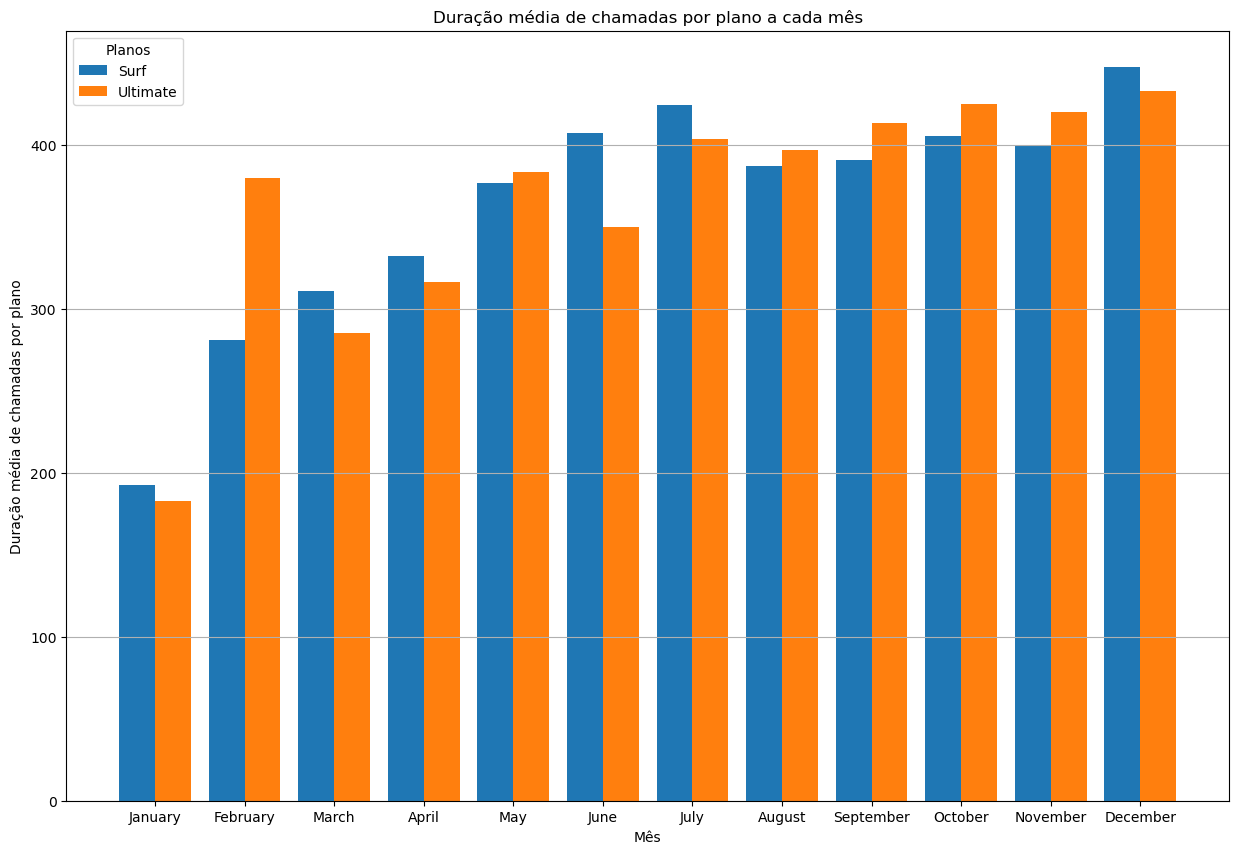

        month      plan  total_minutes
8     January      surf         192.84
9     January  ultimate         183.16
6    February      surf         280.85
7    February  ultimate         379.86
15      March  ultimate         285.70
14      March      surf         310.97
0       April      surf         332.38
1       April  ultimate         316.51
17        May  ultimate         383.66
16        May      surf         377.05
13       June  ultimate         349.81
12       June      surf         407.21
11       July  ultimate         403.77
10       July      surf         424.52
3      August  ultimate         397.27
2      August      surf         387.17
22  September      surf         390.99
23  September  ultimate         413.29
20    October      surf         405.69
21    October  ultimate         425.17
18   November      surf         399.60
19   November  ultimate         420.48
5    December  ultimate         433.01
4    December      surf         447.48


In [33]:
# Compare a duração média das chamadas de cada plano para cada mês. Crie um gráfico de barras para visualizar o resultado.

#Cria uma lista chamada 'month_order' que separa cada mês na ordem correta para o gráfico
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

#Cria o dataframe 'df_minutes_per_plan_monthly' que agrupa as colunas 'month' e 'plan' de df_user_monthly_usage com a média de 'total minutes'
df_minutes_per_plan_monthly = df_user_monthly_usage.groupby(['month', 'plan'])['total_minutes'].mean().round(2).reset_index()

#Ordena a categoria dos meses na ordem correta
df_minutes_per_plan_monthly['month'] = pd.Categorical(df_minutes_per_plan_monthly['month'], categories = month_order, ordered = True)
df_minutes_per_plan_monthly = df_minutes_per_plan_monthly.sort_values('month')

#Separa os dados dos planos para o gráfico
data_surf = df_minutes_per_plan_monthly[df_minutes_per_plan_monthly['plan'] == 'surf']
data_ultimate = df_minutes_per_plan_monthly[df_minutes_per_plan_monthly['plan'] == 'ultimate']
#Sepada todos os meses únicos
months = df_minutes_per_plan_monthly['month'].cat.categories
#Cria um array para a posição de barras no eixo x e determina a largura de cada barra
x = np.arange(len(months))
width = 0.40

#Cria o gráfico de barras
plt.figure(figsize = (15, 10))
plt.bar(x - width/2, data_surf['total_minutes'], width, label = 'Surf')
plt.bar(x + width/2, data_ultimate['total_minutes'], width, label = 'Ultimate')
plt.title('Duração média de chamadas por plano a cada mês')
plt.xlabel('Mês')
plt.ylabel('Duração média de chamadas por plano')
plt.legend(title = 'Planos')
plt.xticks(x, months)
plt.grid(axis = 'y')
plt.show()

print(df_minutes_per_plan_monthly.head(24))

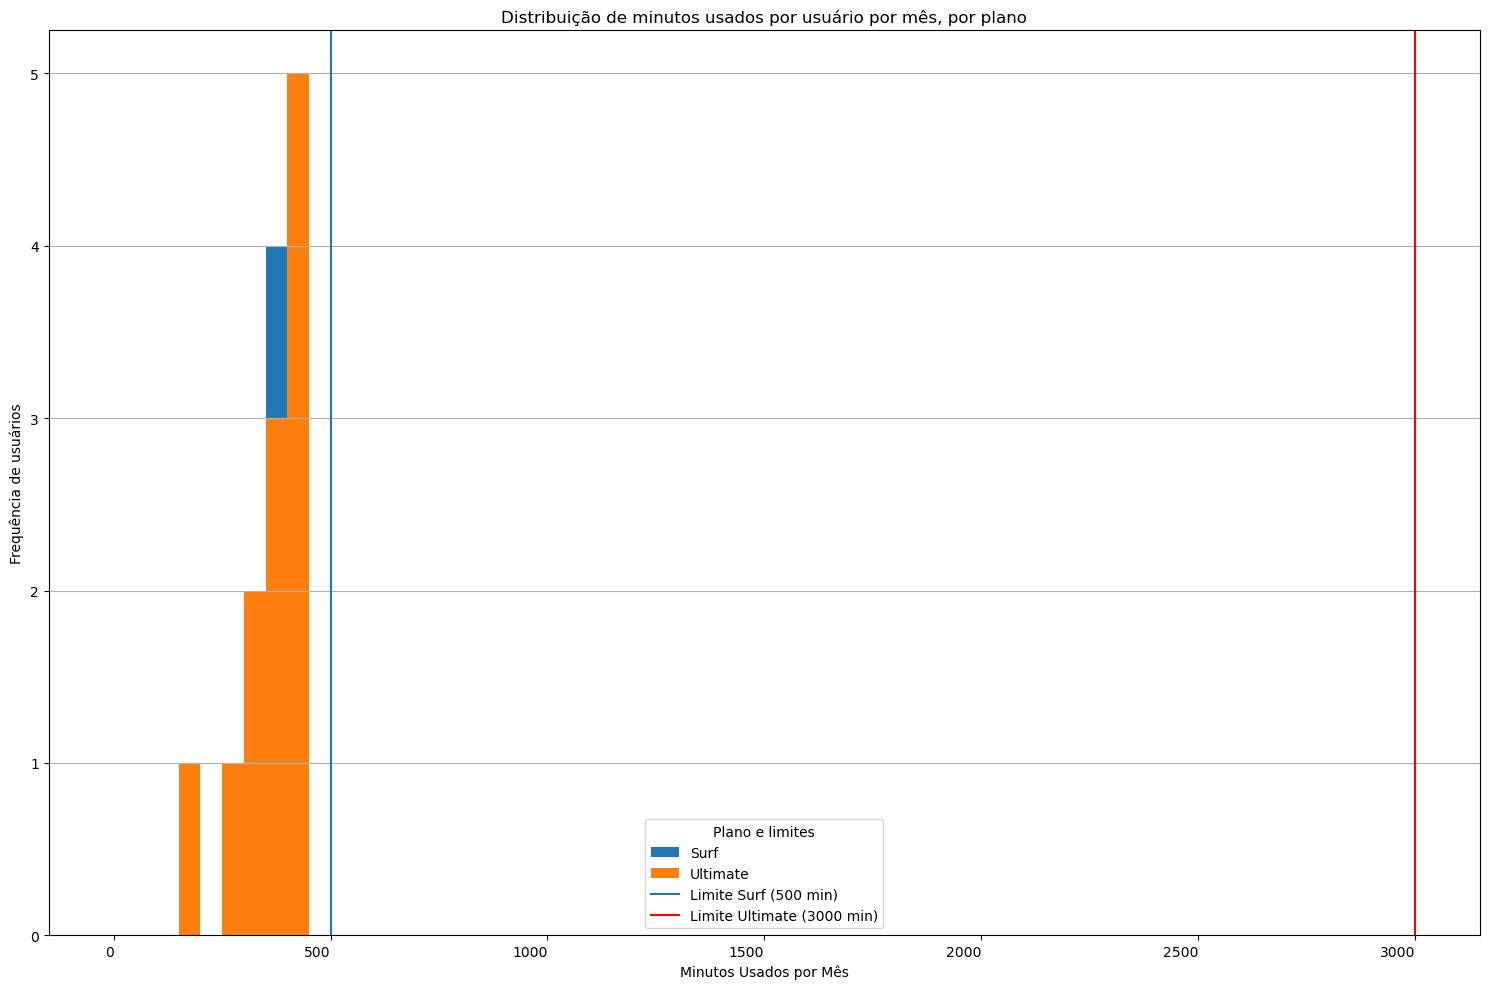

          count        mean        std     min       25%      50%       75%  \
plan                                                                          
surf       12.0  363.062500  71.953798  192.84  327.0275  389.080  406.0700   
ultimate   12.0  365.974167  73.046765  183.16  341.4850  390.465  415.0875   

             max  
plan              
surf      447.48  
ultimate  433.01  


In [34]:
# Compare o número de minutos que os usuários de cada plano necessitam a cada mês. Construa um histograma.

data_surf_minutes = df_minutes_per_plan_monthly[df_minutes_per_plan_monthly['plan'] == 'surf']['total_minutes']
data_ultimate_minutes = df_minutes_per_plan_monthly[df_minutes_per_plan_monthly['plan'] == 'ultimate']['total_minutes']

#Atribui o valor máximo de 'total minutes' para 'max_minutes'
max_minutes = int(df_minutes_per_plan_monthly['total_minutes'].max())
#Separa as barras por cada 50 minutos gastos
bins = range(0, max_minutes + 50, 50)

#Cria o histograma
plt.figure(figsize=(15, 10))
plt.hist(data_surf_minutes, bins = bins, label = 'Surf')
plt.hist(data_ultimate_minutes, bins = bins, label = 'Ultimate')
#Adiciona linhas para os limites de minutos incluídos em cada plano
plt.axvline(x = df_plans[df_plans['plan_name'] == 'surf']['minutes_included'].iloc[0], label = 'Limite Surf (500 min)')
plt.axvline(x = df_plans[df_plans['plan_name'] == 'ultimate']['minutes_included'].iloc[0], label = 'Limite Ultimate (3000 min)', color = 'red')
plt.title('Distribuição de minutos usados por usuário por mês, por plano')
plt.xlabel('Minutos Usados por Mês')
plt.ylabel('Frequência de usuários')
plt.legend(title = 'Plano e limites')
plt.grid(axis = 'y')
plt.xticks(ha = 'right')
plt.tight_layout()
plt.show()

print(df_minutes_per_plan_monthly.groupby('plan')['total_minutes'].describe())

In [35]:
# Calcule a média e a variância da duração mensal das chamadas

#Cria o dataframe 'df_monthly_calls_mean_var' que agrupa 'df_minutes_per_plan_monthly' por plano e calcula a média e a variância dos minutos totais
df_monthly_calls_mean_var = df_minutes_per_plan_monthly.groupby('plan')['total_minutes'].agg(['mean', 'var']).round(2)

In [36]:
print(df_monthly_calls_mean_var)

            mean      var
plan                     
surf      363.06  5177.35
ultimate  365.97  5335.83


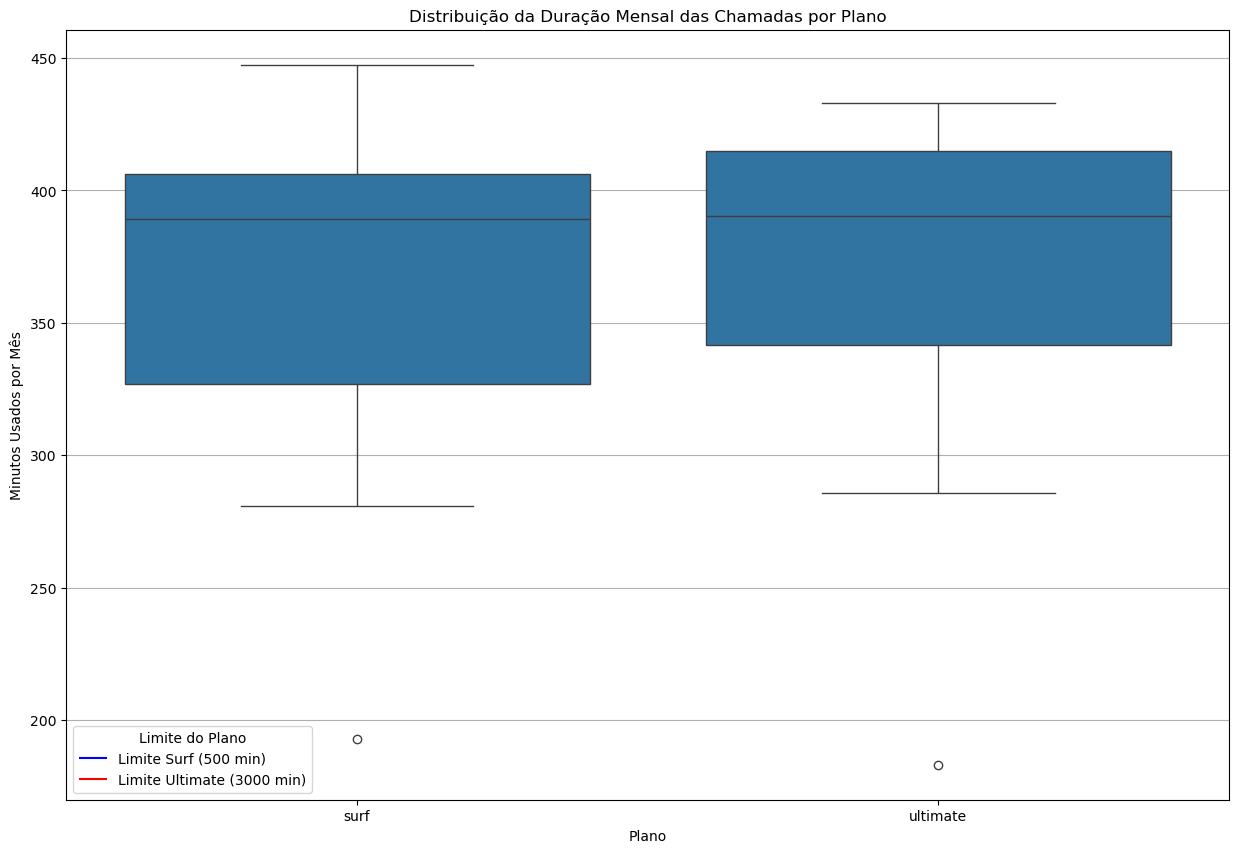

In [37]:
# Faça um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas

#Cria o diagrama
plt.figure(figsize = (15, 10))
data_surf_minutes_limit = df_user_monthly_usage[df_user_monthly_usage['plan'] == 'surf']['minutes_included']
data_ultimate_minutes_limit = df_user_monthly_usage[df_user_monthly_usage['plan'] == 'ultimate']['minutes_included']
#Cria uma linha que determina o limite de minutos de minutos dos planos Surf e Ultimate
plt.hlines(y = data_surf_minutes_limit, xmin = -0.4, xmax = 0.4, color = 'blue', label = 'Limite Surf (500 min)')
plt.hlines(y = data_ultimate_minutes_limit, xmin = 0.6, xmax = 1.4, color = 'red', label = 'Limite Ultimate (3000 min)')
sns.boxplot(data = df_minutes_per_plan_monthly, x = 'plan', y = 'total_minutes')
plt.title('Distribuição da Duração Mensal das Chamadas por Plano')
plt.xlabel('Plano')
plt.ylabel('Minutos Usados por Mês')
plt.grid(axis = 'y')
plt.legend(title = 'Limite do Plano')
plt.show()

****

**Analisando a média, o histograma e o diagrama de caixa do uso dos planos, pode-se perceber que não há uma grande diferença entre o tempo de chamadas entre usuários dos planos Surf e Ultimate.**

**Além de terem uma média muito próxima, os assinantes de ambos os planos nunca passam de 500 minutos por mês, que seria o limite de minutos do plano Surf.**

**A única grande diferença notável seria nas médias mensais das durações das chamadas, com assinantes do plano Surf tendo médias maiores nos meses de Janeiro, Março, Abril, Junho, Julho e Dezembro enquanto assinantes do plano ultimate estão mais ativos nos meses de Fevereiro, Maio, Agosto, Setembro, Outubro e Novembro**

****

### Mensagens

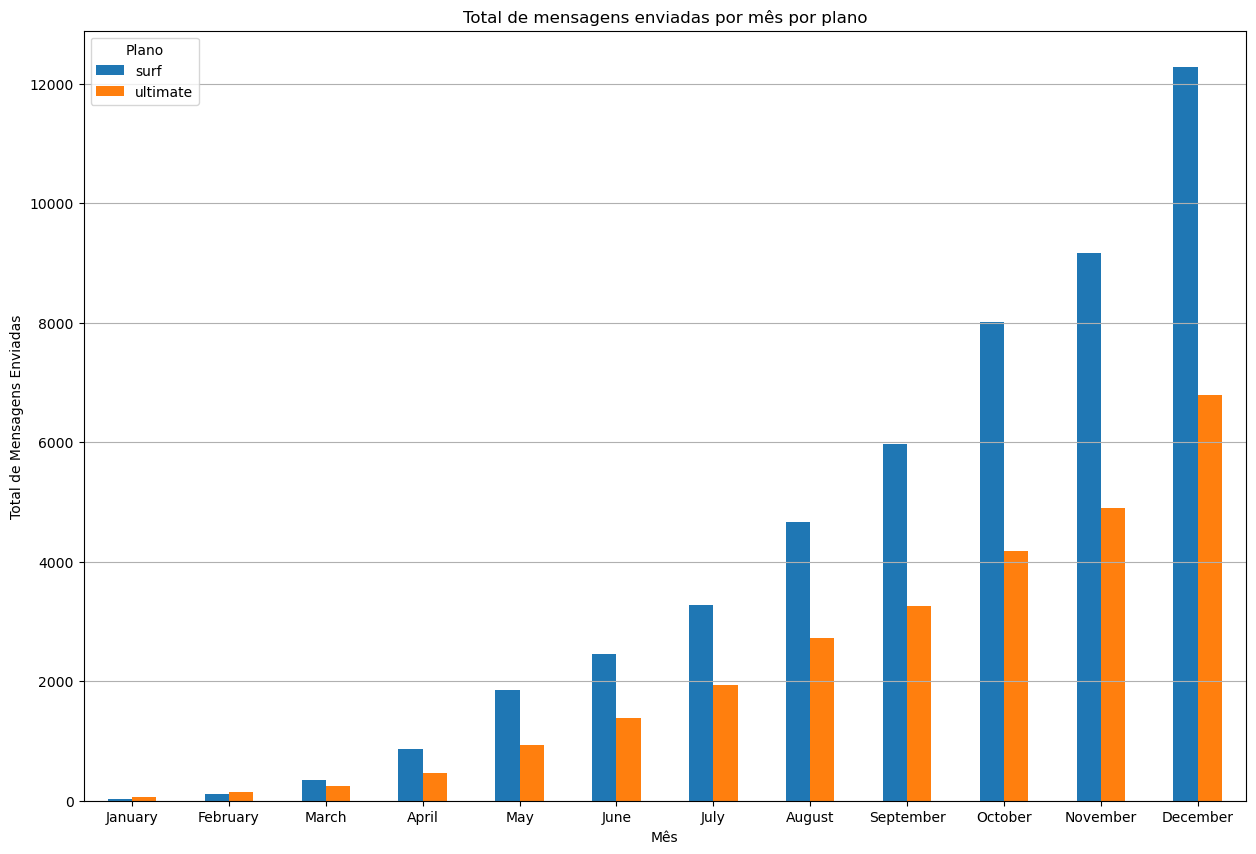

plan          surf  ultimate
month                       
January       21.0      62.0
February     108.0     151.0
March        351.0     243.0
April        870.0     463.0
May         1849.0     931.0
June        2454.0    1379.0
July        3271.0    1937.0
August      4662.0    2732.0
September   5968.0    3259.0
October     8020.0    4181.0
November    9165.0    4903.0
December   12275.0    6796.0


In [38]:
# Compare o número de mensagens que os usuários de cada plano costumam enviar a cada mês

df_messages_per_plan_monthly = df_user_monthly_usage.groupby(['month', 'plan'])['total_messages'].sum().unstack()

month_order_messages = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

df_messages_per_plan_monthly = df_messages_per_plan_monthly.reindex(month_order_messages)

df_messages_per_plan_monthly.plot(figsize = (15, 10), kind = 'bar')
plt.title('Total de mensagens enviadas por mês por plano')
plt.xlabel('Mês')
plt.ylabel('Total de Mensagens Enviadas')
plt.xticks(rotation = 0)
plt.grid(axis = 'y')
plt.legend(title = 'Plano')
plt.show()

print(df_messages_per_plan_monthly.head(12))

In [39]:
# Compare a quantidade de tráfego de internet consumido pelos usuários por plano

#Verifica a média e a variança do número de megas usados por usuários entre os dois planos
df_internet_traffic_per_plan_monthly_var_mean = df_user_monthly_usage.groupby('plan')['total_mb_used'].agg(['mean', 'var']).round(2)
print(df_internet_traffic_per_plan_monthly_var_mean)

              mean          var
plan                           
surf      16558.28  64216395.84
ultimate  17214.70  61652293.32


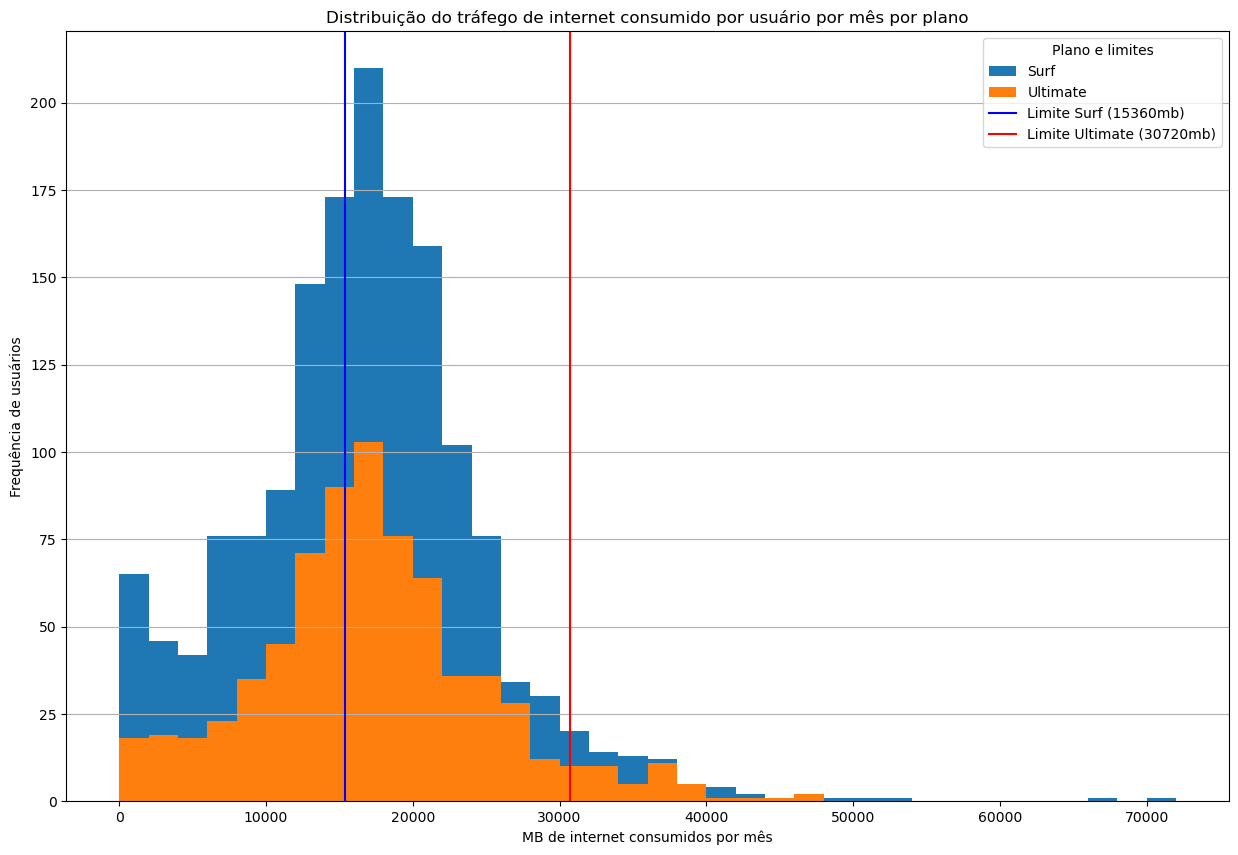

          count          mean          std      min         25%       50%  \
plan                                                                        
surf       12.0  14464.553333  3642.890909  4874.86  13053.7900  15820.39   
ultimate   12.0  16212.602500  3057.988478  6918.09  16288.9675  17001.78   

                 75%       max  
plan                            
surf      16786.5325  18132.47  
ultimate  17663.0925  18323.19  


In [40]:
#Histograma de distribuição de internet em megabytes

plt.figure(figsize=(15, 10))

data_surf_mb = df_user_monthly_usage[df_user_monthly_usage['plan'] == 'surf']['total_mb_used']
data_ultimate_mb = df_user_monthly_usage[df_user_monthly_usage['plan'] == 'ultimate']['total_mb_used']

max_mb = df_user_monthly_usage['total_mb_used'].max()

#Cria um bin a cada 2000mb (aprox. 2gb)
bins_internet = np.arange(0, max_mb + 2000, 2000)

plt.hist(data_surf_mb, bins = bins_internet, label = 'Surf')
plt.hist(data_ultimate_mb, bins = bins_internet, label = 'Ultimate')

surf_mb_limit = df_plans[df_plans['plan_name'] == 'surf']['mb_per_month_included'].iloc[0]
ultimate_mb_limit = df_plans[df_plans['plan_name'] == 'ultimate']['mb_per_month_included'].iloc[0]
plt.axvline(x = surf_mb_limit, color = 'blue', label = 'Limite Surf (15360mb)')
plt.axvline(x = ultimate_mb_limit, color = 'red', label = 'Limite Ultimate (30720mb)')
plt.title('Distribuição do tráfego de internet consumido por usuário por mês por plano')
plt.xlabel('MB de internet consumidos por mês')
plt.ylabel('Frequência de usuários')
plt.legend(title = 'Plano e limites')
plt.grid(axis= 'y')
plt.show()

df_internet_traffic_per_plan_monthly = df_user_monthly_usage.groupby(['month', 'plan'])['total_mb_used'].mean().round(2).reset_index()

print(df_internet_traffic_per_plan_monthly.groupby('plan')['total_mb_used'].describe())

****

**Analisando o gráfico de barras das mensagens enviadas e a média, variança e o histograma do consumo de megabytes, pode-se perceber que há uma grande diferença entre os usuários dos planos Surf e Ultimate.**

**O total de mensagens enviadas por usuários do plano Surf são maiores que o total de mensagens enviadas por usuários do plano Ultimate em todos os meses do ano exceto em Janeiro e Fevereiro.**

**A média e a variança do uso de internet entre usuários dos planos Surf e Ultimate terem valores próximos indica que usuários do plano Surf usam uma quantidade de internet similar a de usuários do plano ultimate, isso é perceptível pelo gráfico de histograma, que mostra que muitos clientes que pagam o plano Surf ultrapassam o limite do plano (15360mbs), assim, tendo que pagar mais do que os 20 dólares base do plano, Enquanto poucos usuários do plano Ultimte ultrapassam o limite de dados mensais (30720mbs), assim, em sua maioria, pagando apenas os 70 dólares base.**

****

### Internet

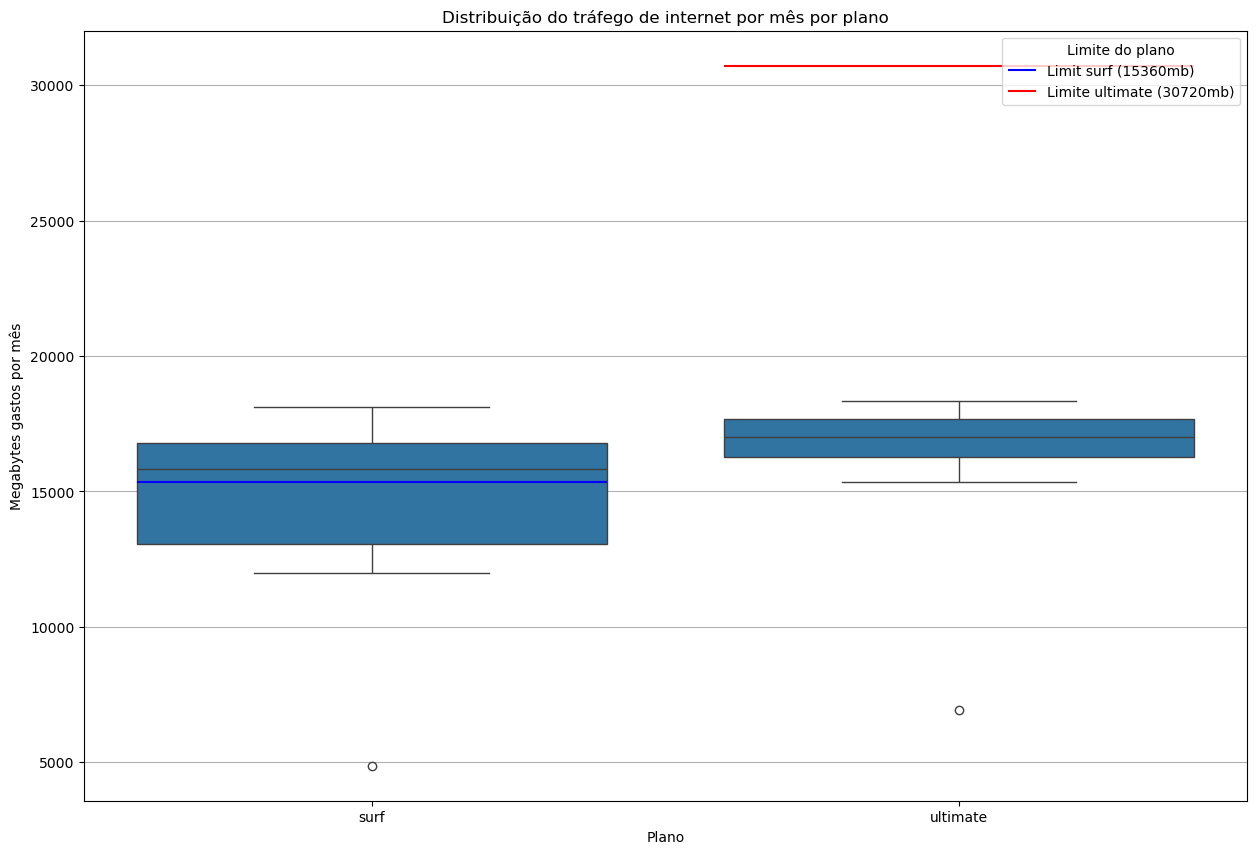

In [41]:
#Diagrama de caixa da distribuição de internet

plt.figure(figsize = (15, 10))
sns.boxplot(data = df_internet_traffic_per_plan_monthly, x = 'plan', y = 'total_mb_used')
plt.hlines(y = surf_mb_limit, xmin = -0.4, xmax = 0.4, color = 'blue', label = 'Limit surf (15360mb)')
plt.hlines(y = ultimate_mb_limit, xmin = 0.6, xmax = 1.4, color = 'red',label = 'Limite ultimate (30720mb)')
plt.title('Distribuição do tráfego de internet por mês por plano')
plt.xlabel('Plano')
plt.ylabel('Megabytes gastos por mês')
plt.grid(axis = 'y')
plt.legend(title = 'Limite do plano')
plt.show()

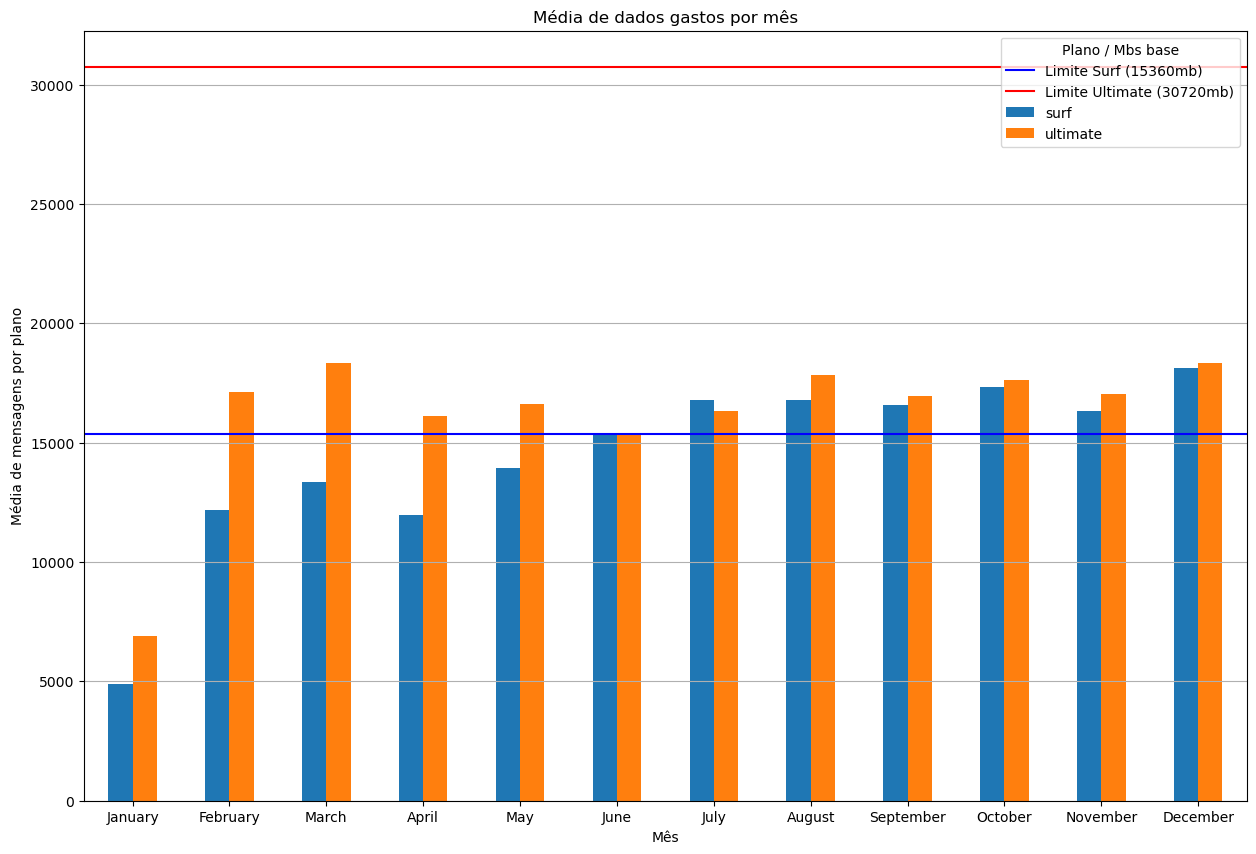

plan               surf      ultimate
month                                
January     4874.860000   6918.092500
February   12178.843333  17128.808571
March      13345.440000  18321.518333
April      11984.203000  16121.654762
May        13936.354935  16624.482414
June       15301.529175  15337.921064
July       16783.600579  16344.744407
August     16795.331358  17814.720141
September  16591.431289  16969.869535
October    17311.335063  17612.553396
November   16339.254417  17033.685354
December   18132.469371  18323.191854


In [42]:
#Gráfico de barras da média de uso de dados por mês por plano

df_avg_internet_per_month_plan = df_user_monthly_usage.groupby(['month', 'plan'])['total_mb_used'].mean().unstack()

month_order_mbs = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

df_avg_internet_per_month_plan = df_avg_internet_per_month_plan.reindex(month_order_mbs)

df_avg_internet_per_month_plan.plot(figsize = (15, 10), kind = 'bar')
plt.title('Média de dados gastos por mês')
plt.xlabel('Mês')
plt.ylabel('Média de mensagens por plano')
plt.xticks(rotation = 0)
plt.grid(axis = 'y')
surf_base_mbs = df_plans[df_plans['plan_name'] == 'surf']['mb_per_month_included'].iloc[0]
ultimate_base_mbs = df_plans[df_plans['plan_name'] == 'ultimate']['mb_per_month_included'].iloc[0]
plt.axhline(y = surf_base_mbs, color = 'blue', label = 'Limite Surf (15360mb)')
plt.axhline(y = ultimate_base_mbs, color = 'red', label = 'Limite Ultimate (30720mb)')
plt.legend(title = 'Plano / Mbs base')
plt.show()

print(df_avg_internet_per_month_plan.head(12))

****

**Analisando o diagrama de caixa e o gráfico de barras do consumo de megabytes, pode-se perceber que há uma diferença entre os usuários dos planos Surf e Ultimate.**

**Novamente percebe-se que mensalmente usuários do plano Surf ultrapassam mais seus limites de megabytes do que usuários do plano Ultimate, indicando que os assinantes do plno surf geralmente pagam mais do que quem assina do plano Ultimate.**

**Isso é mais notável ainda no gráfico de barras das médias mensais de megas gastos, onde a partir do mês de julho a média de mbs de usuários Surf superam o limite de dados de 15360mbs enquanto a média de usuários Ultimate sempre está abaixo do limite.**

****

## Receita

In [43]:
#Verifica a média e a variança da receita gerada pelos usuários entre os dois planos
df_revenue_var_mean_by_plan = df_user_monthly_usage.groupby('plan')['total_monthly_revenue'].agg(['mean', 'var']).round(2)
print(df_revenue_var_mean_by_plan)

           mean      var
plan                    
surf      57.29  2887.54
ultimate  72.12   115.97


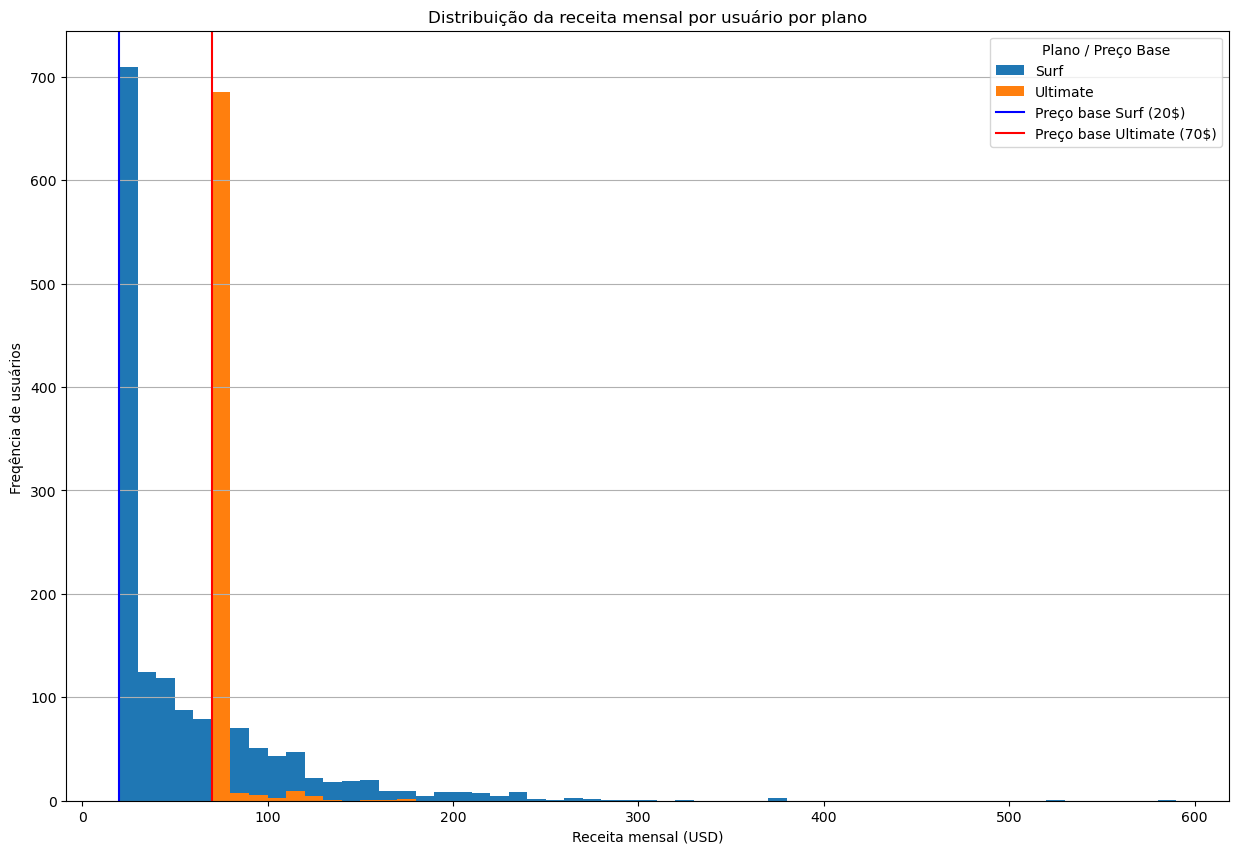

In [44]:
#Histograma que verifica a distribuição de receitas mensais

plt.figure(figsize = (15, 10))
data_surf_revenue = df_user_monthly_usage[df_user_monthly_usage['plan'] == 'surf']['total_monthly_revenue'].round(2)
data_ultimate_revenue = df_user_monthly_usage[df_user_monthly_usage['plan'] == 'ultimate']['total_monthly_revenue'].round(2)
min_revenue = min(df_user_monthly_usage['usd_monthly_pay'].min() for _, row in df_plans.iterrows())
max_revenue = df_user_monthly_usage['total_monthly_revenue'].max()
bins_revenue = np.arange(min_revenue, max_revenue + 10, 10)
plt.hist(data_surf_revenue, bins = bins_revenue, label = 'Surf')
plt.hist(data_ultimate_revenue, bins = bins_revenue, label = 'Ultimate')
surf_base_price = df_plans[df_plans['plan_name'] == 'surf']['usd_monthly_pay'].iloc[0]
ultimate_base_price = df_plans[df_plans['plan_name'] == 'ultimate']['usd_monthly_pay'].iloc[0]
plt.axvline(x = surf_base_price, color = 'blue', label = 'Preço base Surf (20$)')
plt.axvline(x = ultimate_base_price, color = 'red', label = 'Preço base Ultimate (70$)')
plt.title('Distribuição da receita mensal por usuário por plano')
plt.xlabel('Receita mensal (USD)')
plt.ylabel('Freqência de usuários ')
plt.legend(title = 'Plano / Preço Base')
plt.grid(axis = 'y')
plt.show()

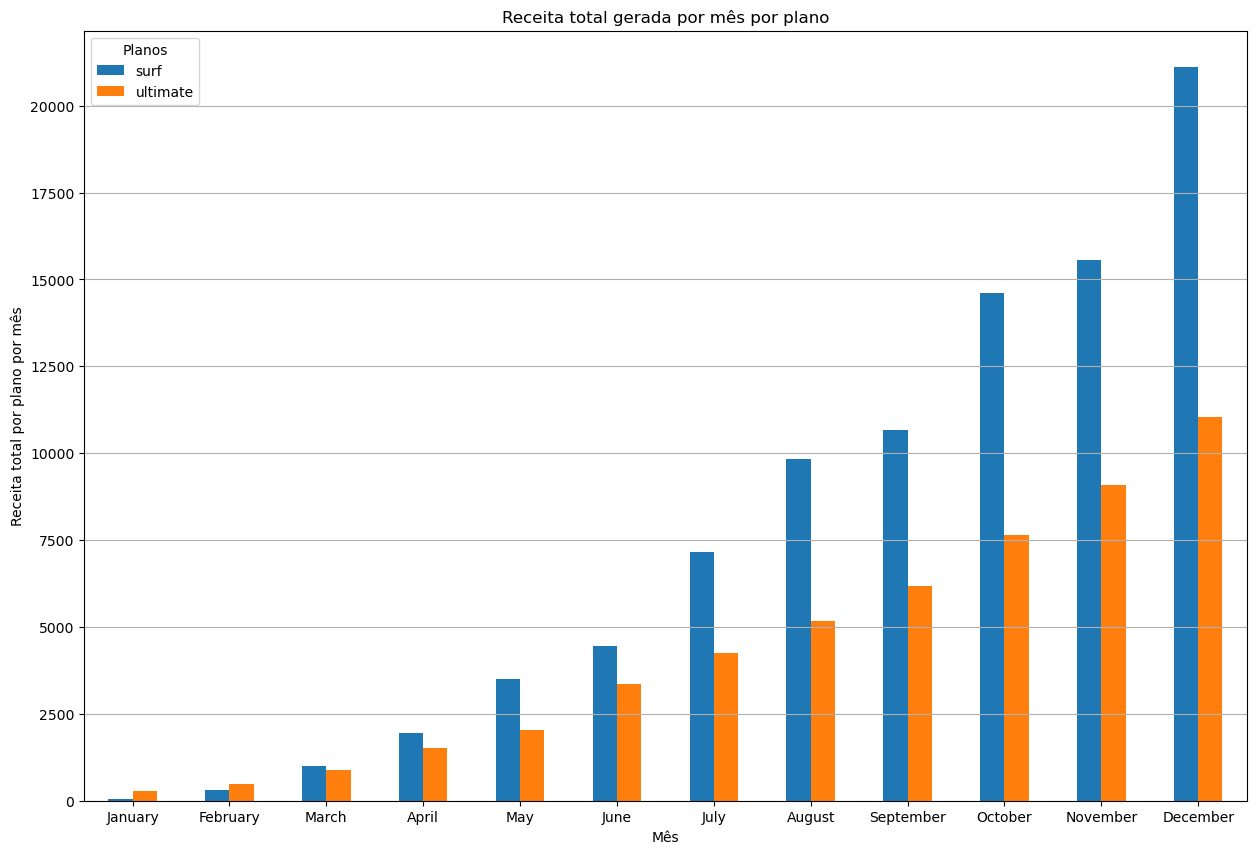

plan               surf      ultimate
month                                
January       40.000000    280.000000
February     297.035600    490.000000
March       1002.312133    880.709375
April       1938.874258   1528.198916
May         3491.678287   2044.955869
June        4454.303370   3359.418057
July        7159.723945   4239.174434
August      9825.320625   5160.287275
September  10655.194925   6175.858623
October    14610.214048   7641.719053
November   15545.777833   9093.352871
December   21102.687315  11029.902871


In [45]:
#Gráfico de barras do total da receita mensal por planos

df_monthly_revenue_by_plan = df_user_monthly_usage.groupby(['month', 'plan'])['total_monthly_revenue'].sum().unstack()

month_order_revenue = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

df_monthly_revenue_by_plan = df_monthly_revenue_by_plan.reindex(month_order_revenue)

df_monthly_revenue_by_plan.plot(figsize = (15, 10), kind = 'bar')
plt.title('Receita total gerada por mês por plano')
plt.xlabel('Mês')
plt.ylabel('Receita total por plano por mês')
plt.xticks(rotation = 0)
plt.grid(axis = 'y')
plt.legend(title = 'Planos')
plt.show()

print(df_monthly_revenue_by_plan.head(12))

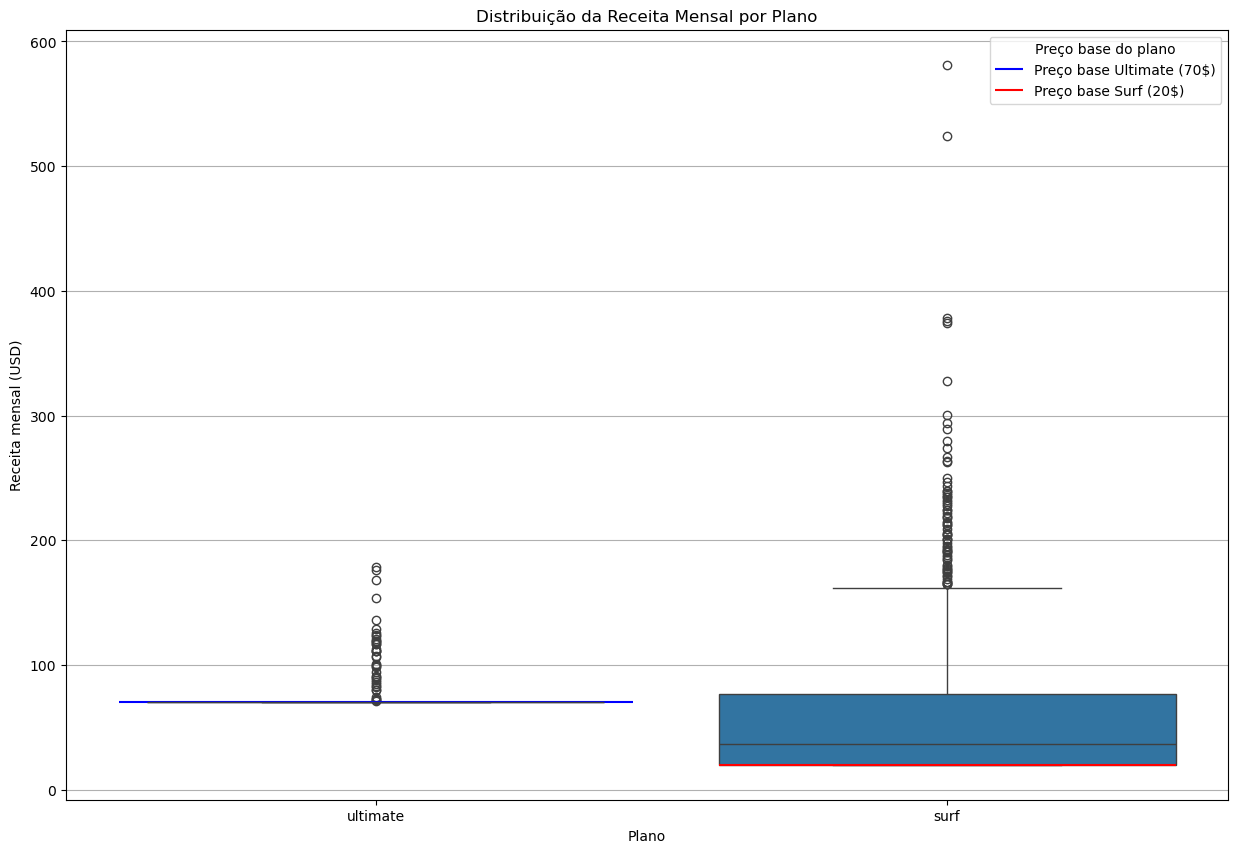

In [46]:
#Diagrama de Caixa da Distribuição das Receitas Mensais

plt.figure(figsize = (15, 10))
sns.boxplot(data = df_user_monthly_usage, x = 'plan', y = 'total_monthly_revenue')
plt.hlines(y = ultimate_base_price, xmin = -0.45, xmax = 0.45, color = 'blue', label = 'Preço base Ultimate (70$)')
plt.hlines(y = surf_base_price, xmin = 0.6, xmax = 1.4, color = 'red', label = 'Preço base Surf (20$)')
plt.title('Distribuição da Receita Mensal por Plano')
plt.xlabel('Plano')
plt.ylabel('Receita mensal (USD)')
plt.grid(axis = 'y')
plt.legend(title = 'Preço base do plano')
plt.show()

****

**Analisando a média e variança, o histograma, o gráfico de barras e o diagrama de caixa da receita gerada por usuários, pode-se perceber que há uma grande diferença entre os usuários dos planos Surf e Ultimate.**

**Percebe-se primeiramente que a variança da receita gerada por usuários do plano Surf é extremamente maior do que a variança do da receita gerada por usuários do plano Ultimate, sendo aproximadamente 25 vezes maior, assim indicando uma dispersão de receita muito maior entre usuários do plano Surf.**

**Observando o histograma de distribuição da receita mensal por usuário percebe-se que muitos usuários do plano Surf acabam pagando além dos 20 dólares base, muitos inclusive pagando 70 dólares ou mais, o preço padrão do plano Ultimate, o histograma assim nos indica que os usuários do plano Surf geram mais receita do que usuários do plano Ultimate. Enquanto isso, poquíssimos usuários do plano Ultimate geram mais receita do que o preço base de 70 dólares, assim possívelemte gerando menos lucro para a Megaline.**

**Observando o gráfico de barras das receitas totais geradas por mês por plano, percebe-se que com excessão dos meses de janeiro e fevereiro, o plano Surf sempre gera mais lucros mensalmente do que o plano Ultimate.**

**Por ultimo percebe-se pelo diagrama de caixa que os valores do plano Ultimate estão baixamente distribuídos, indicando uma baixíssima variedade de receita, enquanto o plano Surf está mais distribuído, indicando uma quantidade muito maior de usuários que pagam além do preço do plano base.**

****

## Teste hipóteses estatísticas

****

**Hipótese Nula: A receita média dos usuários do plano Ultimate é igual a receita média dos usuários do plano Surf.**

**Hipótese Alternativa: A receita média dos usuários do plano Ultimate é diferente da receita média dos usuários do plano Surf.**

****

In [47]:
# Teste as hipóteses

#1. Separar as receitas por plano e arrendonda os valores
surf_revenue = df_user_monthly_usage[df_user_monthly_usage['plan'] == 'surf']['total_monthly_revenue'].round(2)
ultimate_revenue = df_user_monthly_usage[df_user_monthly_usage['plan'] == 'ultimate']['total_monthly_revenue'].round(2)

#2. Determinar alpha
alpha = 0.05

#3. Verificar se há igualdade de variâncias usando o teste de Levene
levene_test_stat, levene_p_value = st.levene(surf_revenue, ultimate_revenue)

print(f'Variância da Receita Surf: ${surf_revenue.var():.2f}')
print(f'Variância da Receita Ultimate: ${ultimate_revenue.var():.2f}')
print(f'Valor-p do Teste de Levene para igualdade de variâncias: {levene_p_value:.3f}')

equal_variances = False
if levene_p_value > alpha:
    equal_variances = True
    print('Assumimos variâncias iguais para o teste t (p-valor de Levene > alpha)')
else:
    print('Assumimos variâncias desiguais para o teste t (p-valor de Levene <= alpha)')

#4. Realizar um teste t ttest_ind para testar as hipóteses
results = st.ttest_ind(surf_revenue, ultimate_revenue, equal_var = equal_variances)

print('Valor-p:', results.pvalue)
if results.pvalue < alpha:
    print('Rejeitamos a hipótese nula')
    print('Existe uma diferença estatística significante entre as receitas geradas pelos usuários dos planos Surf e Ultimate')
else:
    print('Não podemos rejeitar a hipótese nula')
    print('As receitas geradas entre usuários dos planos Surf e Ultimate possuem valores muito similares')

Variância da Receita Surf: $2887.55
Variância da Receita Ultimate: $115.97
Valor-p do Teste de Levene para igualdade de variâncias: 0.000
Assumimos variâncias desiguais para o teste t (p-valor de Levene <= alpha)
Valor-p: 4.881957436054138e-25
Rejeitamos a hipótese nula
Existe uma diferença estatística significante entre as receitas geradas pelos usuários dos planos Surf e Ultimate


****

**Hipótese nula: As receitas médias de usuários das áreas de NY e NJ são similares as de usuários de outras regiões.**

**Hipótese alternativa: As receitas médias dos usuários em NY e NJ são diferentes das de usuários de outras regiões.**

****

In [48]:
#0: Adicionar as informações de cidade em 'df_user_monthly_usage' para facilitar na filtragem dos usuários

df_user_monthly_usage = df_user_monthly_usage.merge(df_users[['user_id', 'city']], on = 'user_id', how = 'left')

In [49]:
# Teste as hipóteses

#1. Filtar usuários da região de NY-NJ pelos usuários de outras regiões
df_ny_nj_users = df_user_monthly_usage[df_user_monthly_usage['city'] == 'New York-Newark-Jersey City, NY-NJ-PA MSA']['total_monthly_revenue'].round(2)
df_other_region_users = df_user_monthly_usage[df_user_monthly_usage['city'] != 'New York-Newark-Jersey City, NY-NJ-PA MSA']['total_monthly_revenue'].round(2)  

#2. Determinar alpha
alpha = 0.05

#3. Verificar se há igualdade de variâncias usando o teste de Levene
levene_test_stat, levene_p_value = st.levene(surf_revenue, ultimate_revenue)

print(f'Variância da Região de NY-NJ: ${df_ny_nj_users.var():.2f}')
print(f'Variância das outras Regiões: ${df_other_region_users.var():.2f}')
print(f'Valor-p do Teste de Levene para igualdade de variâncias: {levene_p_value:.3f}')

equal_variances = False
if levene_p_value > alpha:
    equal_variances = True
    print('Assumimos variâncias iguais para o teste t (p-valor de Levene > alpha)')
else:
    print('Assumimos variâncias desiguais para o teste t (p-valor de Levene <= alpha)')

#4. Realizar um teste t ttest_ind para testar as hipóteses
results = st.ttest_ind(df_ny_nj_users, df_other_region_users, equal_var = equal_variances)

print('Valor-p:', results.pvalue)
if results.pvalue < alpha:
    print('Rejeitamos a hipótese nula')
    print('Existe uma diferença estatística significante entre as receitas geradas pelos usuários de NY-NJ comparado com o resto das regiões')
else:
    print('Não podemos rejeitar a hipótese nula')
    print('As receitas geradas entre usuários das regiões de NY-NJ possuem valores muito similares com a receita gerada por usuários de outras regiões')

Variância da Região de NY-NJ: $1777.75
Variância das outras Regiões: $2116.18
Valor-p do Teste de Levene para igualdade de variâncias: 0.000
Assumimos variâncias desiguais para o teste t (p-valor de Levene <= alpha)
Valor-p: 0.018609727488845786
Rejeitamos a hipótese nula
Existe uma diferença estatística significante entre as receitas geradas pelos usuários de NY-NJ comparado com o resto das regiões


## Conclusão geral

****

**Analizando os resultados finais, pode-se concluir que o plano Surf gera mais lucro para a Megaline, ou seja, seria ideal para o departamento comercial promove-lo mais em seu ajuste publicitário.**

****